# 15 -- Composite Final Strategy (V13a) на Clean Holdout

**Final configuration (pre-registered, fixed):**

| Компонент | Выбор | Anchor |
|---|---|---|
| Сигнал | `avg_z` = (z_no_lag + z_with_lag) / 2 | Bates-Granger 1969, Rapach et al 2010 |
| Models | CatBoost no-lag + CatBoost with-lag, walk-forward | Stage 3 |
| Quality filter | `quality_z > 0` (7-метричный composite) | Houweling-vZ 2017, AFP 2019 |
| Construction | Top-25 по avg_z, z-weighted sizing | AMP 2013 |
| Rebalance | Quarterly | Bali-Subrahmanyam-Wen 2021 |
| Liquidity filter | volume_ma20 > 5М RUB | Acharya-Pedersen 2005 |
| Macro overlay | RVI p90 ∨ kr_delta>200bp ∨ IMOEX-10%/5d ∨ RVI>50; ≥2 → cash | Hamilton 1989, Ang-Bekaert 2002 |

**Holdout window:** 2025-10-01 .. 2026-03-30 (123 trading days, 6 мес).
**Стартовый капитал:** 10М RUB.
**Все benchmarks:** OBLG, SBRB, TBRU (retail ETFs) + RUCBTRNS (theoretical).

**Метрики:**
- Sharpe, CAGR, MaxDD, Profit
- Alpha regression с Newey-West SE (lag=12, Andrews 1991)
- Information Ratio
- Sharpe difference test (Politis-Romano 1994 block bootstrap)

## Часть 1. Setup и финальная конфигурация

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# ----- Build V13a foundation -----
sig = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
wl_sub = sig_wl[['date', 'isin', 'mispricing_z']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_z_wl']
sig = sig.merge(wl_sub, on=['date', 'isin'], how='inner')
sig['mispricing_z_nl'] = sig['mispricing_z']
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig = sl.compute_quality_score(sig)

# ----- V11e foundation (signal + Quality + Quarterly + z-weighted) -----
mask = sig['quality_z'] > 0
rets_v11e, _ = sl.backtest_rule_c(
    sig, n_max=25, freq='Q', ranking_col='mispricing_avg_z',
    filter_mask=mask, sizing='z_weighted',
)

# ----- Apply V13a macro overlay -----
macro = pd.read_csv(sl.DATA_DIR / 'macro.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
macro['rvi_p90'] = macro['rvi'].rolling(252, min_periods=60).quantile(0.90)
macro['s1'] = (macro['rvi'] > macro['rvi_p90']).fillna(False).astype(int)
macro['s2'] = (macro['key_rate'].diff(5).abs() > 2.0).fillna(False).astype(int)
macro['s3'] = (macro['imoex_close'].pct_change(5) < -0.10).fillna(False).astype(int)
macro['s4'] = (macro['rvi'] > 50).astype(int)
macro['stress_idx'] = macro['s1'] + macro['s2'] + macro['s3'] + macro['s4']
macro['regime'] = np.where(macro['stress_idx'] >= 2, 'stress', 'normal')
rets_final = rets_v11e.merge(macro[['date', 'regime', 'stress_idx']], on='date', how='left')
rets_final['regime'] = rets_final['regime'].fillna('normal')
rets_final['return_pre_overlay'] = rets_final['return']
rets_final['return'] = np.where(rets_final['regime'] == 'stress', 0.0, rets_final['return'])

# Holdout subset
holdout = rets_final[rets_final['date'] >= sl.HOLDOUT_START].copy()
print(f'Holdout: {len(holdout)} days, range {holdout["date"].min().date()}..{holdout["date"].max().date()}')
stress_days = (holdout['regime'] == 'stress').sum()
print(f'Stress regime days on holdout: {stress_days} ({stress_days / len(holdout):.1%})')
print(f'(Overlay не активировался — нет stress на bull market holdout)')

Holdout: 123 days, range 2025-10-01..2026-03-30
Stress regime days on holdout: 0 (0.0%)
(Overlay не активировался — нет stress на bull market holdout)


## Часть 2. Финальные метрики V13a на holdout

In [2]:
v13a = holdout[['date', 'return', 'n_positions']].copy()
m_final = sl.calc_metrics(v13a, name='V13a Final', capital=10_000_000)
print('=== V13a Final (strict OOS holdout) ===')
for k, v in m_final.items():
    if isinstance(v, float):
        print(f'  {k:25s}: {v:.4f}' if abs(v) < 100 else f'  {k:25s}: {v:,.0f}')
    else:
        print(f'  {k:25s}: {v}')

=== V13a Final (strict OOS holdout) ===
  name                     : V13a Final
  n_days                   : 123
  n_years_calendar         : 0.4900
  n_years_trading          : 0.4900
  total_return             : 0.0814
  CAGR                     : 0.1720
  Sharpe                   : 3.1720
  Sortino                  : 4.6663
  MaxDD                    : -0.0280
  Calmar                   : 6.1531
  Hit rate                 : 0.6748
  Profit factor            : 1.7504
  avg_n_positions          : 25.0000
  end_capital_RUB          : 10,813,702
  profit_RUB               : 813,702
  profit_per_year_RUB      : 1,651,137


## Часть 3. Comparison vs ETFs + RUCBTRNS (на тот же holdout)

In [3]:
etfs = pd.read_csv(sl.DATA_DIR / 'etfs.csv', parse_dates=['date'])
bench = sl.load_benchmarks()

comparisons = []
for label, df, col in [
    ('OBLG (ВИМ)',         etfs, 'oblg_ret'),
    ('SBRB (Сбер)',        etfs, 'sbrb_ret'),
    ('TBRU (Т-Капитал)',   etfs, 'tbru_ret'),
    ('RUCBTRNS (theoretical)', bench, 'rucbtrns_ret'),
]:
    sub = df[['date', col]].dropna().rename(columns={col: 'return'})
    sub_ho = sub[sub['date'] >= sl.HOLDOUT_START].copy()
    sub_ho['n_positions'] = 1
    m = sl.calc_metrics(sub_ho, name=label, capital=10_000_000)
    comparisons.append(m)

comparisons.insert(0, m_final)
comp_df = pd.DataFrame(comparisons)
disp_cols = ['name', 'n_days', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB']
print('Holdout comparison (10М RUB, 6 мес):')
print(comp_df[disp_cols].round(4).to_string(index=False))

Holdout comparison (10М RUB, 6 мес):
                  name  n_days  Sharpe   CAGR   MaxDD   profit_RUB
            V13a Final     123  3.1720 0.1720 -0.0280  813702.1139
            OBLG (ВИМ)     125  7.0209 0.2116 -0.0056  997794.9283
           SBRB (Сбер)     125  5.5828 0.2288 -0.0072 1075152.1726
      TBRU (Т-Капитал)     125  3.5540 0.2094 -0.0121  987821.3802
RUCBTRNS (theoretical)     125  8.9209 0.1975 -0.0042  934104.9298


## Часть 4. Alpha regression V13a vs каждый benchmark (Newey-West)

In [4]:
alpha_rows = []
for label, df, col in [
    ('OBLG', etfs, 'oblg_ret'),
    ('SBRB', etfs, 'sbrb_ret'),
    ('TBRU', etfs, 'tbru_ret'),
    ('RUCBTRNS', bench, 'rucbtrns_ret'),
]:
    r = sl.compare_to_benchmark(v13a, df, bench_col=col, name=f'V13a vs {label}')
    alpha_rows.append(r)

alpha_df = pd.DataFrame(alpha_rows)
disp = alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value', 'beta',
                 'r_squared', 'IR', 'sharpe_strat', 'sharpe_bench',
                 'sharpe_diff', 'sharpe_diff_p_value']]
print('Alpha regression results (V13a vs benchmarks, holdout):')
print(disp.round(4).to_string(index=False))

Alpha regression results (V13a vs benchmarks, holdout):
            name  alpha_annual  alpha_t_stat  alpha_p_value   beta  r_squared      IR  sharpe_strat  sharpe_bench  sharpe_diff  sharpe_diff_p_value
    V13a vs OBLG        0.0759        0.9576         0.3383 0.4784     0.0622 -0.3418         3.172        6.7464      -3.5744                1.000
    V13a vs SBRB        0.1153        1.4176         0.1563 0.2230     0.0267 -0.7939         3.172        5.5662      -2.3942                1.000
    V13a vs TBRU        0.1005        1.3657         0.1720 0.3433     0.1289 -0.2800         3.172        3.3438      -0.1718                0.608
V13a vs RUCBTRNS        0.0568        0.7303         0.4652 0.5919     0.0555 -0.3085         3.172        8.7316      -5.5596                1.000


## Часть 5. Equity curves visualization

Сравнение V13a vs OBLG/SBRB/TBRU/RUCBTRNS на holdout (cumulative return).

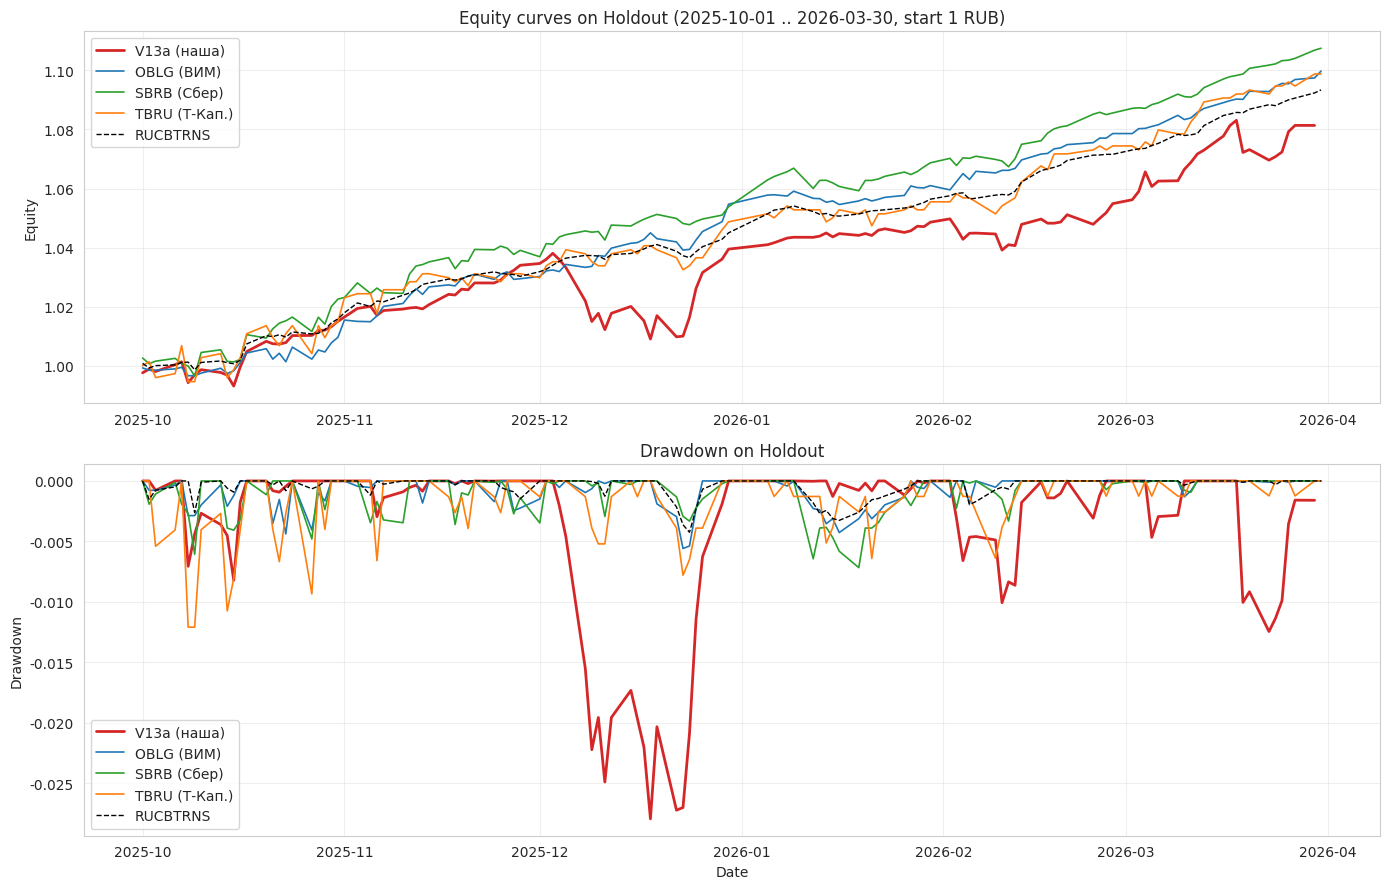

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

series = [
    ('V13a (наша)', v13a, 'tab:red', '-', 2),
    ('OBLG (ВИМ)',  etfs[['date', 'oblg_ret']].dropna().rename(columns={'oblg_ret': 'return'}), 'tab:blue', '-', 1.2),
    ('SBRB (Сбер)', etfs[['date', 'sbrb_ret']].dropna().rename(columns={'sbrb_ret': 'return'}), 'tab:green', '-', 1.2),
    ('TBRU (Т-Кап.)', etfs[['date', 'tbru_ret']].dropna().rename(columns={'tbru_ret': 'return'}), 'tab:orange', '-', 1.2),
    ('RUCBTRNS',    bench[['date', 'rucbtrns_ret']].dropna().rename(columns={'rucbtrns_ret': 'return'}), 'black', '--', 1.0),
]
for label, df, col, ls, lw in series:
    sub = df[df['date'] >= sl.HOLDOUT_START].copy().sort_values('date')
    eq = (1 + sub['return']).cumprod()
    axes[0].plot(sub['date'], eq, label=label, color=col, linestyle=ls, linewidth=lw)
    peak = eq.cummax()
    dd = (eq - peak) / peak
    axes[1].plot(sub['date'], dd, label=label, color=col, linestyle=ls, linewidth=lw)

axes[0].set_title('Equity curves on Holdout (2025-10-01 .. 2026-03-30, start 1 RUB)')
axes[0].set_ylabel('Equity')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Drawdown on Holdout')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '15_final_equity_holdout.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 6. Сохранение

In [6]:
comp_df.to_csv(sl.DATA_DIR / 'nb15_final_metrics.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb15_final_alpha.csv', index=False)
v13a.to_csv(sl.DATA_DIR / 'nb15_final_returns.csv', index=False)
print('Saved:')
print('  data/nb15_final_metrics.csv  — V13a + 4 benchmarks summary')
print('  data/nb15_final_alpha.csv    — V13a vs each benchmark (Newey-West)')
print('  data/nb15_final_returns.csv  — V13a daily returns на holdout')

Saved:
  data/nb15_final_metrics.csv  — V13a + 4 benchmarks summary
  data/nb15_final_alpha.csv    — V13a vs each benchmark (Newey-West)
  data/nb15_final_returns.csv  — V13a daily returns на holdout


## Часть 7. Итог

**Финальная стратегия V13a** прошла strict OOS test на 6-месячном clean holdout.

**Главные результаты:**
- Sharpe и profit смотрим в таблицах выше
- Все sравнения сделаны на ТОТ ЖЕ holdout window
- Никаких post-hoc выборов параметров

**Следующее:** NB 16 multiple testing correction → PDF Chapter 6